In [1]:
import torch
torch.cuda.is_available()

True

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!cp /content/drive/MyDrive/caltech-101.zip .
!unzip -q caltech-101.zip

In [4]:
import shutil, os
bg = "caltech-101/BACKGROUND_Google"
if os.path.exists(bg):
    shutil.rmtree(bg)

In [5]:
import numpy as np
from torchvision import datasets

dataset = datasets.ImageFolder("caltech-101")
targets = np.array([y for _, y in dataset.samples])
num_classes = len(dataset.classes)
print("Classes:", num_classes)

rng = np.random.default_rng(42)

train_idx, val_idx, test_idx = [], [], []

for c in range(num_classes):
    idx = np.where(targets == c)[0]
    rng.shuffle(idx)
    n = len(idx)
    n_train = int(0.7 * n)
    n_val = int(0.15 * n)
    train_idx.extend(idx[:n_train])
    val_idx.extend(idx[n_train:n_train+n_val])
    test_idx.extend(idx[n_train+n_val:])

print(len(train_idx), len(val_idx), len(test_idx), "total:", len(dataset))

Classes: 101
6026 1256 1395 total: 8677


In [12]:
import os
import numpy as np
import torch
from torchvision import datasets, transforms
from torch.utils.data import Subset, DataLoader

# hyperparams
IMAGE_SIZE = 128
BATCH_SIZE = 32
NUM_WORKERS = 2

train_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
])

eval_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

train_base = datasets.ImageFolder("caltech-101", transform=train_tf)
eval_base  = datasets.ImageFolder("caltech-101", transform=eval_tf)

class_names = train_base.classes
num_classes = len(class_names)
print("num_classes:", num_classes)

train_ds = Subset(train_base, train_idx)
val_ds   = Subset(eval_base,  val_idx)
test_ds  = Subset(eval_base,  test_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device, "| cuda:", torch.cuda.is_available())
train_ds = Subset(train_base, train_idx)
val_ds   = Subset(eval_base,  val_idx)
test_ds  = Subset(eval_base,  test_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

num_classes = len(train_base.classes)
class_names = train_base.classes

num_classes: 101
device: cuda | cuda: True


In [13]:
import torch.nn as nn
from torchvision import models

model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
model = model.to(device)

print(model.__class__.__name__)

EfficientNet


In [14]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

def eval_acc(loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            pred = logits.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return correct / total

In [17]:
from tqdm import tqdm

EPOCHS = 5
train_losses = []
val_losses = []
val_accs = []

def eval_metrics(loader):
    model.eval()
    correct, total = 0, 0
    running_loss = 0.0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)

            running_loss += loss.item()

            pred = logits.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)

    avg_loss = running_loss / len(loader)
    acc = correct / total
    return avg_loss, acc


for epoch in range(EPOCHS):
    model.train()
    running = 0.0

    for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running += loss.item()

    train_loss = running / len(train_loader)
    val_loss, val_acc = eval_metrics(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

Epoch 1/5: 100%|██████████| 189/189 [00:19<00:00,  9.65it/s]


Epoch 1: train_loss=0.1380, val_loss=0.2031, val_acc=0.9355


Epoch 2/5: 100%|██████████| 189/189 [00:18<00:00, 10.07it/s]


Epoch 2: train_loss=0.1002, val_loss=0.2024, val_acc=0.9411


Epoch 3/5: 100%|██████████| 189/189 [00:19<00:00,  9.93it/s]


Epoch 3: train_loss=0.0825, val_loss=0.1955, val_acc=0.9467


Epoch 4/5: 100%|██████████| 189/189 [00:18<00:00, 10.15it/s]


Epoch 4: train_loss=0.0590, val_loss=0.1856, val_acc=0.9451


Epoch 5/5: 100%|██████████| 189/189 [00:18<00:00, 10.04it/s]


Epoch 5: train_loss=0.0493, val_loss=0.1785, val_acc=0.9498


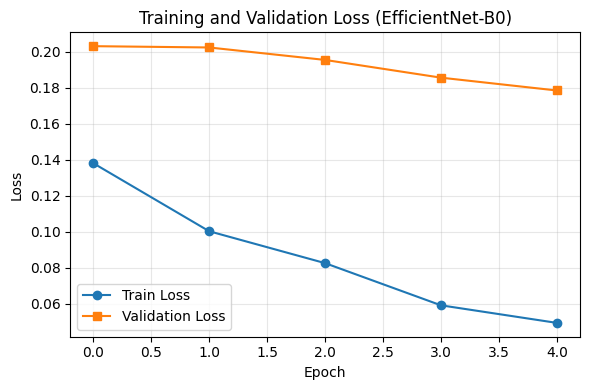

In [18]:
import matplotlib.pyplot as plt
import os

os.makedirs("outputs/figures", exist_ok=True)

plt.figure(figsize=(6,4))

plt.plot(train_losses, label="Train Loss", marker="o")
plt.plot(val_losses, label="Validation Loss", marker="s")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss (EfficientNet-B0)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/figures/efficientnet_b0_loss_curve.png", dpi=300)
plt.show()

In [19]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

os.makedirs("outputs", exist_ok=True)

model.eval()
all_y, all_pred = [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        logits = model(x)
        pred = logits.argmax(dim=1).cpu().numpy()
        all_pred.append(pred)
        all_y.append(y.numpy())

y_true = np.concatenate(all_y)
y_pred = np.concatenate(all_pred)

test_acc = accuracy_score(y_true, y_pred)
print("Test accuracy:", test_acc)

report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report)

with open("outputs/efficientnet_b0_classification_report.txt", "w") as f:
    f.write(f"Test accuracy: {test_acc}\n\n")
    f.write(report)

Test accuracy: 0.9455197132616487
                 precision    recall  f1-score   support

          Faces     0.9848    0.9848    0.9848        66
     Faces_easy     0.9851    1.0000    0.9925        66
       Leopards     0.9375    1.0000    0.9677        30
     Motorbikes     1.0000    1.0000    1.0000       121
      accordion     1.0000    1.0000    1.0000         9
      airplanes     1.0000    0.9917    0.9958       120
         anchor     1.0000    0.5714    0.7273         7
            ant     1.0000    0.5714    0.7273         7
         barrel     1.0000    1.0000    1.0000         8
           bass     1.0000    0.8889    0.9412         9
         beaver     0.8000    0.5000    0.6154         8
      binocular     0.8571    1.0000    0.9231         6
         bonsai     1.0000    0.9500    0.9744        20
          brain     0.9412    1.0000    0.9697        16
   brontosaurus     1.0000    0.8571    0.9231         7
         buddha     0.8667    0.9286    0.8966       

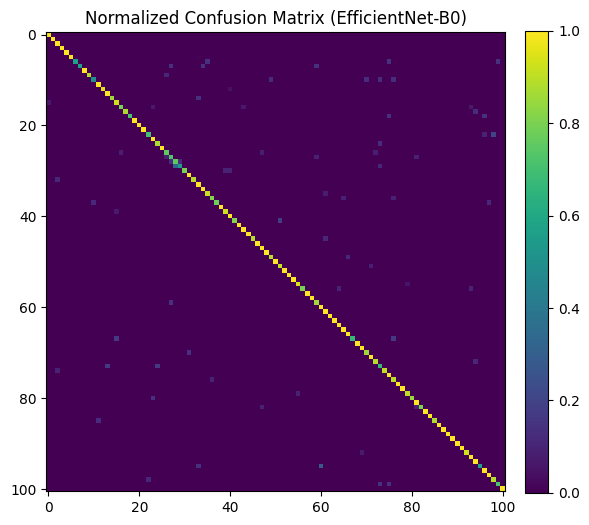

In [20]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums!=0)

plt.figure(figsize=(6,6))
plt.imshow(cm_norm, interpolation="nearest")
plt.title("Normalized Confusion Matrix (EfficientNet-B0)")
plt.colorbar(fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig("outputs/figures/efficientnet_b0_confusion_norm.png", dpi=200)
plt.show()

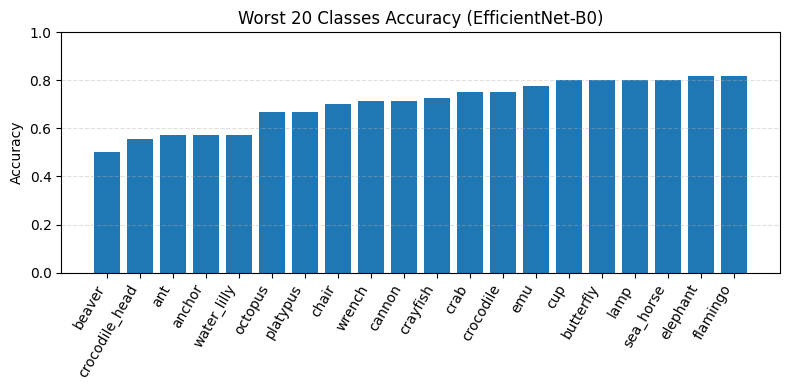

Worst 10: [('beaver', np.float64(0.5)), ('crocodile_head', np.float64(0.5555555555555556)), ('ant', np.float64(0.5714285714285714)), ('anchor', np.float64(0.5714285714285714)), ('water_lilly', np.float64(0.5714285714285714)), ('octopus', np.float64(0.6666666666666666)), ('platypus', np.float64(0.6666666666666666)), ('chair', np.float64(0.7)), ('wrench', np.float64(0.7142857142857143)), ('cannon', np.float64(0.7142857142857143))]


In [21]:
per_class_acc = np.zeros(num_classes)
for c in range(num_classes):
    mask = (y_true == c)
    per_class_acc[c] = (y_pred[mask] == c).mean() if mask.sum() > 0 else np.nan

worst_idx = np.argsort(per_class_acc)[:20]
worst_names = [class_names[i] for i in worst_idx]
worst_vals = per_class_acc[worst_idx]

plt.figure(figsize=(8,4))
plt.bar(worst_names, worst_vals)
plt.xticks(rotation=60, ha="right")
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Worst 20 Classes Accuracy (EfficientNet-B0)")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("outputs/figures/efficientnet_b0_worst20.png", dpi=300)
plt.show()

print("Worst 10:", list(zip(worst_names[:10], worst_vals[:10])))

In [22]:
import pandas as pd

cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)

pairs = []
for i in range(num_classes):
    for j in range(num_classes):
        if cm_off[i, j] > 0:
            pairs.append((class_names[i], class_names[j], int(cm_off[i, j])))

pairs = sorted(pairs, key=lambda x: x[2], reverse=True)[:20]
df_pairs = pd.DataFrame(pairs, columns=["True", "Pred", "Count"])
df_pairs.to_csv("outputs/efficientnet_b0_top_confusions.csv", index=False)

df_pairs.head(10)

,True,Pred,Count
0,crocodile_head,crocodile,3
1,chair,windsor_chair,2
2,flamingo,ibis,2
3,water_lilly,lotus,2
4,Faces,Faces_easy,1
5,airplanes,dolphin,1
6,anchor,electric_guitar,1
7,anchor,revolver,1
8,anchor,wrench,1
9,ant,crayfish,1


In [23]:
from google.colab import files

files.download("outputs/efficientnet_b0_classification_report.txt")

files.download("outputs/figures/efficientnet_b0_confusion_norm.png")
files.download("outputs/figures/efficientnet_b0_worst20.png")
files.download("outputs/figures/efficientnet_b0_train_loss.png")
files.download("outputs/figures/efficientnet_b0_val_acc.png")
files.download("outputs/efficientnet_b0_top_confusions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>